# Phase 1 — EDA & Dimensionality Reduction
### Unsupervised Anomaly Detection for Predictive Maintenance

**Dataset:** AI4I 2020 Predictive Maintenance Dataset (Matzka, 2020) — 10,000 milling-machine process records, 5 failure modes, 3.4% failure rate.


In [1]:
%cd /content/drive/MyDrive/pm-anomaly-detection/src


/content/drive/MyDrive/pm-anomaly-detection/src


In [2]:
import sys, os

from data_loader import load_raw, split_features_labels, basic_sanity_checks
from features import add_feature_engg, encode_type, FEATURE_SETS
from dimensionality_reduction import run_pca, run_umap
import visualize as viz

import warnings; warnings.filterwarnings('ignore')


In [4]:
!pip install -r requirements.txt

#1. Load Data & Quarantine labels

In [5]:
data = load_raw() #change the path from data_loader.py
features, labels = split_features_labels(data)
basic_sanity_checks(data)

{'n_rows': 10000,
 'n_duplicates': 0,
 'n_missing_total': 0,
 'failure_rate_pct': np.float64(3.39),
 'type_distribution': {'L': 0.6, 'M': 0.3, 'H': 0.1}}

#2. Class Imbalance & Failure Mode Breakdown

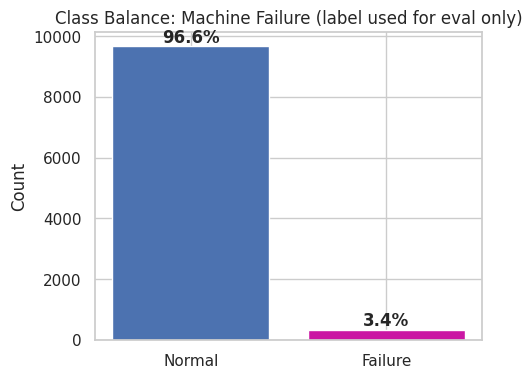

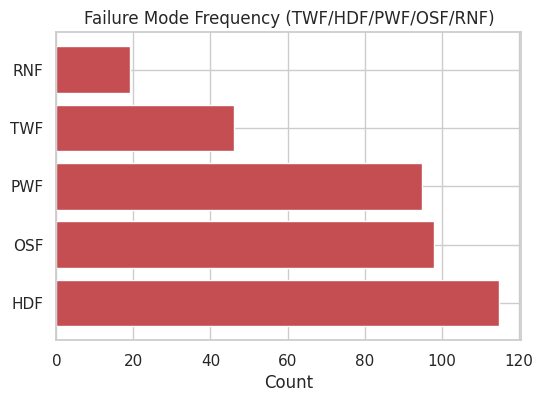

In [16]:
viz.plot_class_imbalance(labels)
viz.plot_failure_mode_breakdown(labels);

#3. Feature Bound Feature Engineering


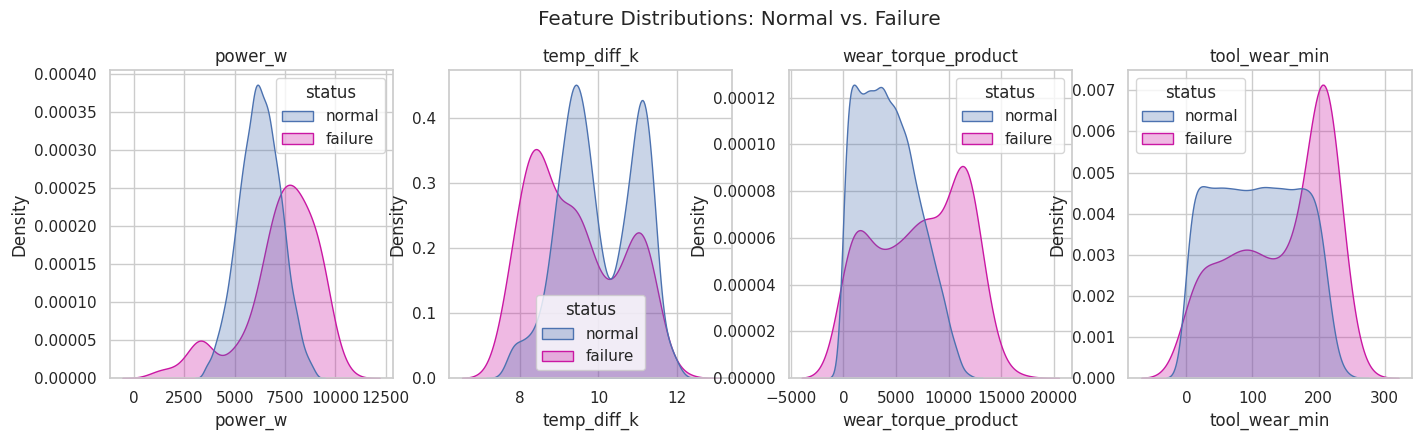

In [19]:
features_eng = add_feature_engg(features)
features_encoded = encode_type(features_eng)

viz.plot_feature_distributions(
    features_eng, labels,
    cols=['power_w', 'temp_diff_k', 'wear_torque_product', 'tool_wear_min']
);

#4. Multicolinearity Warning

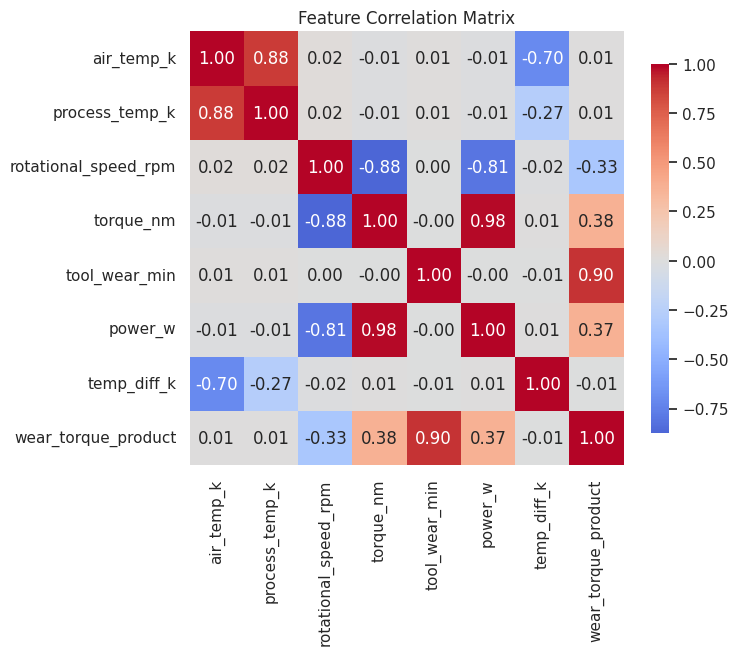

In [20]:
viz.plot_correlation_heatmap(features_eng, cols=FEATURE_SETS['engineered']);

**Reading this — an important nuance for the ablation study:** `power_w` correlates 0.98 with `torque_nm`, and `wear_torque_product` correlates 0.90 with `tool_wear_min`. In this operating range, rotational speed varies narrowly, so power is almost a linear rescaling of torque — meaning `power_w` may add little *new* signal despite being physically motivated. This is exactly why Phase 3 ablates `raw` vs. `engineered` feature sets rather than assuming engineered features are automatically better.

#5. Dimensionality Reduction

Components needed for 90% variance: 5 / 12


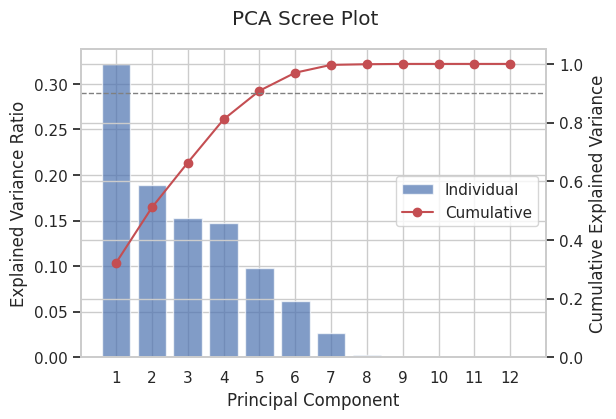

In [21]:
X = features_encoded[[c for c in features_encoded.columns if c not in ('udi', 'product_id')]]

pca_full = run_pca(X, n_components=None)
viz.plot_pca_scree(pca_full.explained_variance_ratio, pca_full.cumulative_variance)

n_90 = int((pca_full.cumulative_variance < 0.90).sum() + 1)
print(f'Components needed for 90% variance: {n_90} / {X.shape[1]}')

PC1: 32.2%, PC2: 18.9%


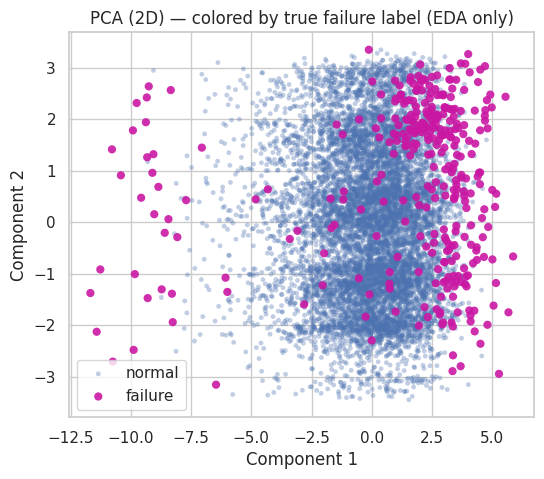

In [22]:
pca_2d = run_pca(X, n_components=2)
viz.plot_2d_embedding(pca_2d.embedding, labels,
                       title='PCA (2D) — colored by true failure label (EDA only)',
                       save_as='06_pca_2d_embedding.png')
print(f"PC1: {pca_full.explained_variance_ratio[0]:.1%}, PC2: {pca_full.explained_variance_ratio[1]:.1%}")

#6. Non-linear Component to PCA (UMAP)

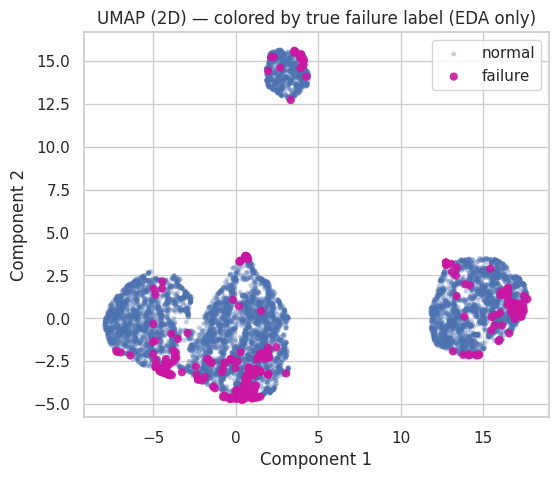

In [23]:
umap_2d = run_umap(X)
viz.plot_2d_embedding(umap_2d, labels,
                       title='UMAP (2D) — colored by true failure label (EDA only)',
                       save_as='07_umap_2d_embedding.png');

**Reading this:** UMAP resolves three well-separated islands — these correspond to the one-hot `type` (L/M/H) columns dominating local neighborhood structure, something PCA's global variance view doesn't foreground as sharply. Within each island, failures cluster along specific low-density edges rather than being scattered uniformly. That's a genuinely useful diagnostic: **PCA tells us about global linear variance (mostly driven by process physics), UMAP tells us about local neighborhood structure (mostly driven by product type)** — showing both, and explaining why they disagree, is the point of doing both, not redundancy.



PCA shows failures aren't linearly separable (interleave with normal points, ruling out reconstruction-error-alone as sufficient); **~5/12** components hit **90%** variance; **UMAP** reveals product-type as a confounding cluster driver that PCA's global-variance view misses — which is why the project uses both instead of picking one arbitrarily.